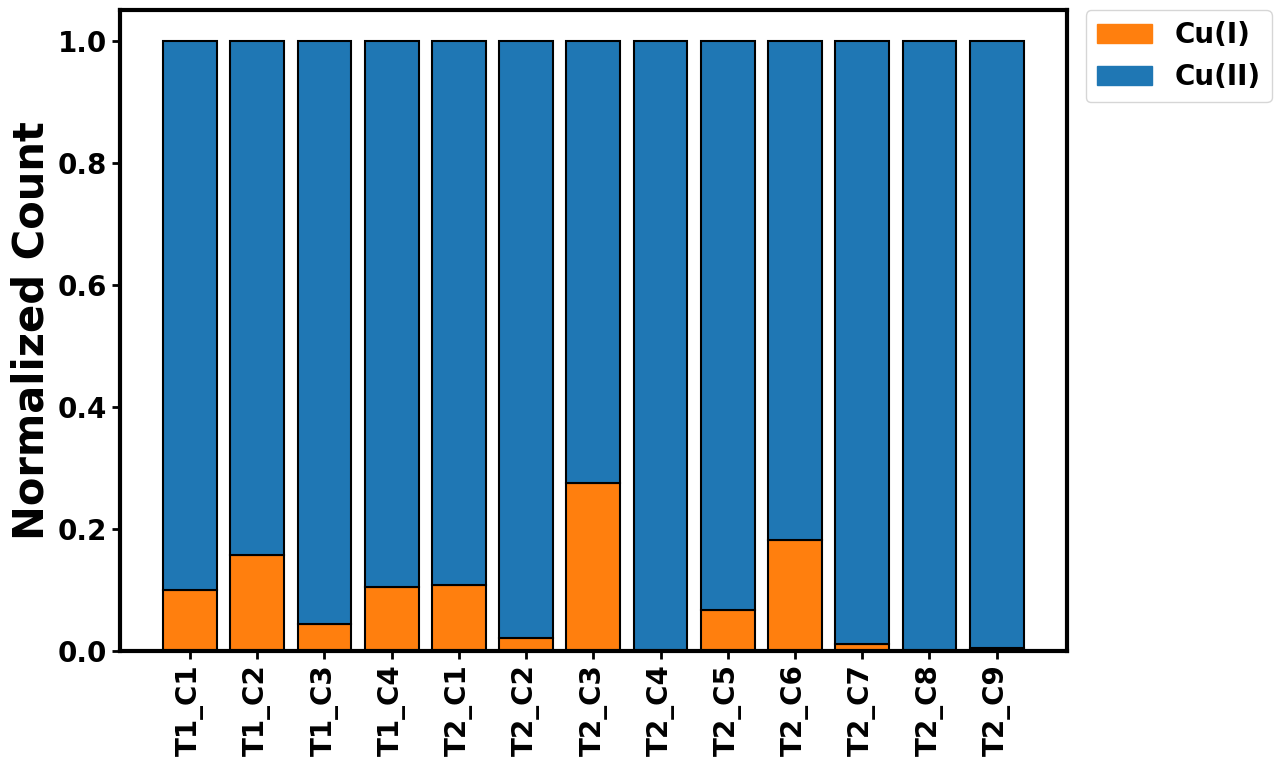

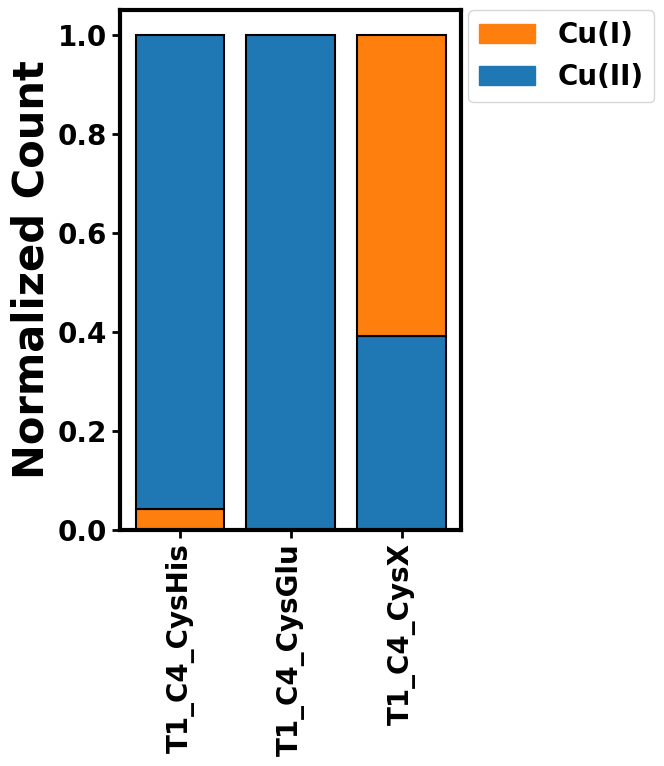

In [2]:
# Distribution of Cu(I) and Cu(II) across the 13 classes
import pandas as pd
import matplotlib.pyplot as plt

# LOAD AND PREPROCESS DATA
df = pd.read_csv("output.csv")

df["CU_Type"] = df["CU_Type"].astype(str).str.strip()
df["Cluster_Label"] = df["Cluster_Label"].astype(int)


# GLOBAL PLOT SETTINGS
plt.rcParams.update({
    "font.size": 18,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 22,
    "axes.labelsize": 25,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20
})


# CLUSTER LABEL MAP
cluster_label_map = {
    1: "T1_C1_CysMet",
    2: "T1_C3_CysGly",
    3: "T1_C2_CysGln",
    4: "T1_C4_CysHis",
    5: "T1_C4_CysGlu",
    6: "T1_C4_CysX",
    7: "T2_C1_His-A",
    8: "T2_C1_His-B",
    9: "T2_C2_Ile",
    10: "T2_C2_Lys",
    11: "T2_C2_His-HOH-A",
    12: "T2_C2_His-HOH-B",
    13: "T2_C2-Gln",
    14: "T2_C2-Arg",
    15: "T2_C2-Gly",
    16: "T2_C3_Met-His",
    17: "T2_C3_Met-X",
    18: "T2_C4_O-A",
    19: "T2_C4_O-B",
    20: "T2_C5_ArA",
    21: "T2_C5_ArB",
    22: "T2_C6_ThrVal",
    23: "T2_C6_ThrCys",
    24: "T2_C6_Thr/Val",
    25: "T2_C7_Asn",
    26: "T2_C7_Ser",
    27: "T2_C8_Ala",
    28: "T2_C9_Asp",
    29: "T2_C9_Glu-A",
    30: "T2_C9_Glu-B"
}


# CREATE CLASS GROUP MAPPING
class_map = {}

for k, v in cluster_label_map.items():

    parts = v.split("_")
    class_label = f"{parts[0]}_{parts[1]}"

    class_map[k] = class_label


df["Class_Group"] = df["Cluster_Label"].map(class_map)


# COMMON FUNCTION FOR CU(I)/CU(II) NORMALIZATION
def calculate_normalized_counts(data, group_column):

    counts = (
        data
        .groupby([group_column, "CU_Type"])
        .size()
        .unstack(fill_value=0)
    )

    for col in ["CU1", "CU2"]:
        if col not in counts.columns:
            counts[col] = 0

    counts = counts[["CU1", "CU2"]]

    counts = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    return counts

# PLOT FUNCTION
def plot_normalized_stacked_bar(
    counts,
    labels,
    figsize,
    filename
):

    fig, ax = plt.subplots(figsize=figsize)

    x = range(len(counts))

    for i, (cluster, row) in enumerate(counts.iterrows()):

        cu1 = row["CU1"]
        cu2 = row["CU2"]

        if cu1 <= cu2:

            bottom_val = cu1
            bottom_color = "#FF7F0E"

            top_val = cu2
            top_color = "#1F77B4"

        else:

            bottom_val = cu2
            bottom_color = "#1F77B4"

            top_val = cu1
            top_color = "#FF7F0E"

        ax.bar(
            i,
            bottom_val,
            color=bottom_color,
            edgecolor="black",
            linewidth=1.5
        )

        ax.bar(
            i,
            top_val,
            bottom=bottom_val,
            color=top_color,
            edgecolor="black",
            linewidth=1.5
        )

    ax.set_xticks(list(x))

    ax.set_xticklabels(
        labels,
        rotation=90,
        ha="center",
        fontweight="bold"
    )

    ax.set_xlabel(
        "",
        fontsize=30,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Normalized Count",
        fontsize=30,
        fontweight="bold"
    )

    ax.set_ylim(0, 1.05)

    ax.set_yticks(
        [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    )

    handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            color="#FF7F0E"
        ),
        plt.Rectangle(
            (0, 0),
            1,
            1,
            color="#1F77B4"
        )
    ]

    ax.legend(
        handles,
        ["Cu(I)", "Cu(II)"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0.
    )

    for spine in ax.spines.values():
        spine.set_linewidth(3)

    ax.tick_params(
        width=2,
        length=6
    )

    plt.tight_layout(
        rect=[0, 0, 0.88, 1]
    )

    plt.savefig(
        filename,
        dpi=1500,
        bbox_inches="tight"
    )

    plt.show()


# PLOT 1: ALL 13 CLASSES
desired_order = [
    "T1_C1",
    "T1_C2",
    "T1_C3",
    "T1_C4",
    "T2_C1",
    "T2_C2",
    "T2_C3",
    "T2_C4",
    "T2_C5",
    "T2_C6",
    "T2_C7",
    "T2_C8",
    "T2_C9"
]

class_counts = calculate_normalized_counts(
    df,
    "Class_Group"
)

class_counts = class_counts.reindex(
    desired_order
)

plot_normalized_stacked_bar(
    counts=class_counts,
    labels=class_counts.index,
    figsize=(15, 8),
    filename="Classwise_Normalized_StackedBarplot.png"
)


# PLOT 2: T1_C4 SUBCLUSTERS
selected_clusters = [4, 5, 6]

cluster_counts = calculate_normalized_counts(
    df[df["Cluster_Label"].isin(selected_clusters)],
    "Cluster_Label"
)

cluster_counts = cluster_counts.reindex(
    selected_clusters
)

cluster_counts.index = cluster_counts.index.map(
    cluster_label_map
)

plot_normalized_stacked_bar(
    counts=cluster_counts,
    labels=cluster_counts.index,
    figsize=(8, 8),
    filename="T1_C4_Subclusters_Normalized_StackedBarplot.png"
)

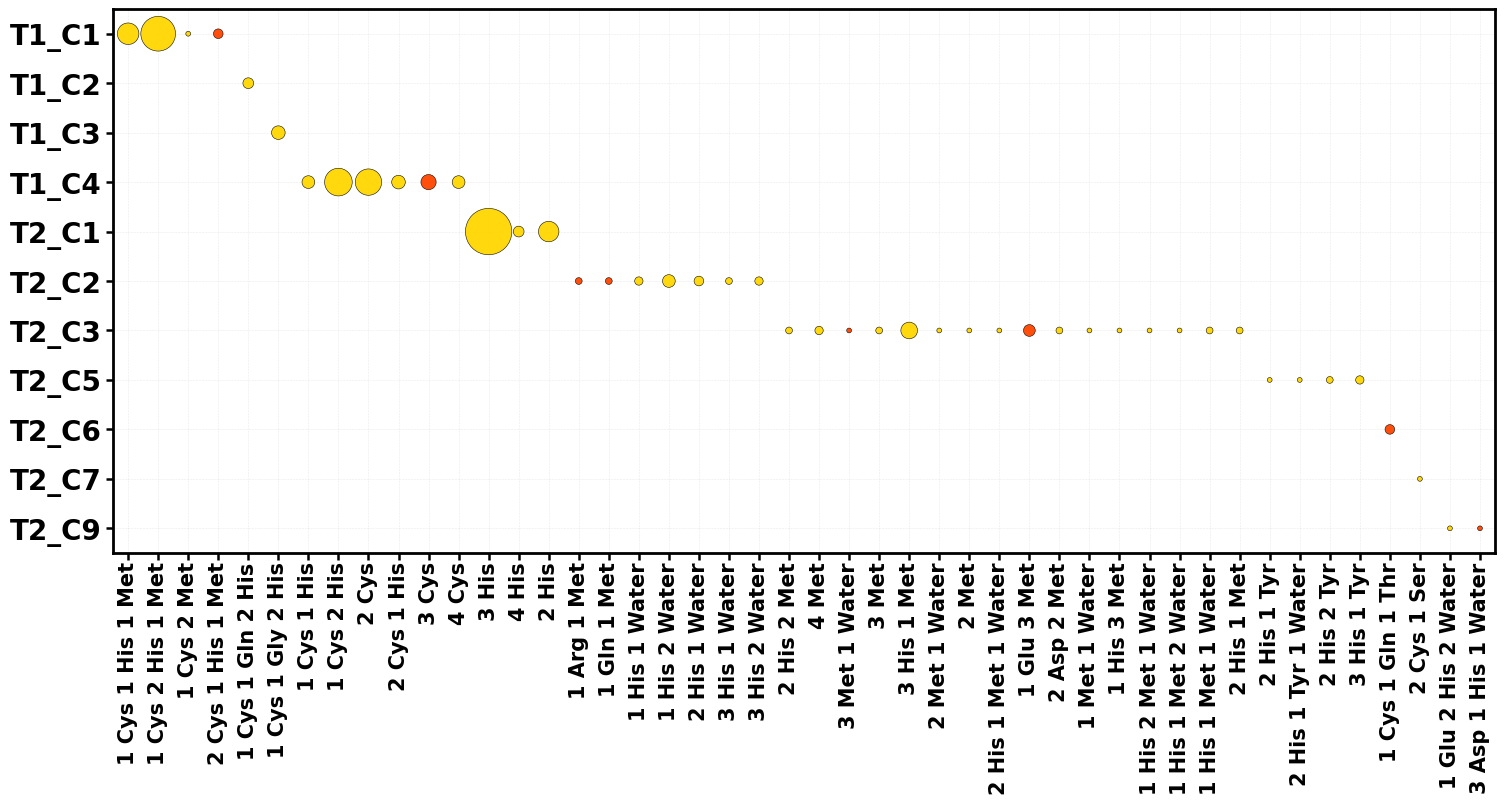

In [3]:
#Bubble plot
import pandas as pd
import matplotlib.pyplot as plt

cluster_label_map = {
    1: "T1_C1_CysMet",
    2: "T1_C3_CysGly",
    3: "T1_C2_CysGln",
    4: "T1_C4_CysHis",
    5: "T1_C4_CysGlu",
    6: "T1_C4_CysX",
    7: "T2_C1_His-A",
    8: "T2_C1_His-B",
    9: "T2_C2_Ile",
    10: "T2_C2_Lys",
    11: "T2_C2_His-HOH-A",
    12: "T2_C2_His-HOH-B",
    13: "T2_C2-Gln",
    14: "T2_C2-Arg",
    15: "T2_C2-Gly",
    16: "T2_C3_Met-His",
    17: "T2_C3_Met-X",
    18: "T2_C4_O-A",
    19: "T2_C4_O-B",
    20: "T2_C5_ArA",
    21: "T2_C5_ArB",
    22: "T2_C6_ThrVal",
    23: "T2_C6_ThrCys",
    24: "T2_C6_Thr/Val",
    25: "T2_C7_Asn",
    26: "T2_C7_Ser",
    27: "T2_C8_Ala",
    28: "T2_C9_Asp",
    29: "T2_C9_Glu-A",
    30: "T2_C9_Glu-B"
}

df = pd.read_csv("output.csv")


df['CU_Type'] = df['CU_Type'].astype(str).str.strip()
df['Cluster_Label'] = df['Cluster_Label'].astype(int)
df['Residue_Combination'] = df['Residue_Combination'].astype(str).str.strip()

aa_map = {
    "ALA": "Ala",
    "ARG": "Arg",
    "ASN": "Asn",
    "ASP": "Asp",
    "CYS": "Cys",
    "GLN": "Gln",
    "GLU": "Glu",
    "GLY": "Gly",
    "HIS": "His",
    "ILE": "Ile",
    "LEU": "Leu",
    "LYS": "Lys",
    "MET": "Met",
    "PHE": "Phe",
    "PRO": "Pro",
    "SER": "Ser",
    "THR": "Thr",
    "TRP": "Trp",
    "TYR": "Tyr",
    "VAL": "Val",
    "WATER": "Water",
    "HOH": "Water"
}

def format_residue_combination(text):
    words = text.split()
    formatted = []
    for word in words:
        formatted.append(aa_map.get(word.upper(), word))
    return " ".join(formatted)

df["Residue_Combination"] = df["Residue_Combination"].apply(format_residue_combination)

cu1_motifs = set(df[df['CU_Type'] == 'CU1']['Residue_Combination'])
cu2_motifs = set(df[df['CU_Type'] == 'CU2']['Residue_Combination'])

unique_cu1 = cu1_motifs - cu2_motifs
common_motifs = cu1_motifs & cu2_motifs


df_cu1 = df[df['CU_Type'] == 'CU1']

counts = (
    df_cu1
    .groupby(['Cluster_Label', 'Residue_Combination'])
    .size()
    .reset_index(name='Count')
)

counts['Cluster_Name'] = counts['Cluster_Label'].map(cluster_label_map)

# Extract main cluster
counts['Main_Cluster'] = counts['Cluster_Name'].str.extract(r'^(T\d+_C\d+)')

counts = (
    counts
    .groupby(['Main_Cluster', 'Residue_Combination'], as_index=False)
    .agg({'Count': 'sum'})
)

cluster_order = [
    "T1_C1",
    "T1_C2",
    "T1_C3",
    "T1_C4",
    "T2_C1",
    "T2_C2",
    "T2_C3",
    "T2_C5",
    "T2_C6",
    "T2_C7",
    "T2_C9",
]

counts['Main_Cluster'] = pd.Categorical(
    counts['Main_Cluster'],
    categories=cluster_order,
    ordered=True
)

counts = counts.sort_values('Main_Cluster')

x_labels = counts['Residue_Combination'].unique()
y_labels = cluster_order

x_map = {label: i for i, label in enumerate(x_labels)}
y_map = {label: i for i, label in enumerate(y_labels)}

counts['x'] = counts['Residue_Combination'].map(x_map)
counts['y'] = counts['Main_Cluster'].map(y_map)

def get_color(motif):
    if motif in unique_cu1:
        return "#FF4500"
    elif motif in common_motifs:
        return "#FFD700"
    else:
        return "#D3D3D3"

counts['color'] = counts['Residue_Combination'].apply(get_color)

fig, ax = plt.subplots(figsize=(15, 8))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.25)

ax.scatter(
    counts['x'],
    counts['y'],
    s=counts['Count'] * 12,
    c=counts['color'],
    edgecolors='black',
    linewidths=0.4,
    alpha=0.95,
    zorder=3
)


ax.set_xlim(-0.5, len(x_labels)-0.5)
ax.set_ylim(len(y_labels)-0.5, -0.5)
ax.set_xticks(range(len(x_labels)))
ax.tick_params(axis='x',
               pad=1,
               labelsize=9,
               width=1.8,
               length=5)

ax.set_xticklabels(
    x_labels,
    rotation=90,
    ha='center',
    fontsize=15,
    fontweight='bold'
)

ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(
    y_labels,
    fontsize=20,
    fontweight='bold'
)

ax.tick_params(axis='y',
               pad=3,
               width=1.8,
               length=5)

for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

plt.tight_layout(pad=0.3)

plt.savefig(
    "CU1_MainCluster_BubblePlot.png",
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()